In [1]:
import numpy as np
import pandas as pd

In [4]:
df = pd.read_csv("/content/placement.csv")
df

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0
...,...,...,...,...
95,95,4.3,200.0,0
96,96,4.4,42.0,0
97,97,6.7,182.0,1
98,98,6.3,103.0,1


In [5]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [6]:
df.shape

(100, 4)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


## 01 Preprocess

In [8]:
df = df.iloc[:,1:]

In [9]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


## 02 EDA

In [10]:
import matplotlib.pyplot as plt

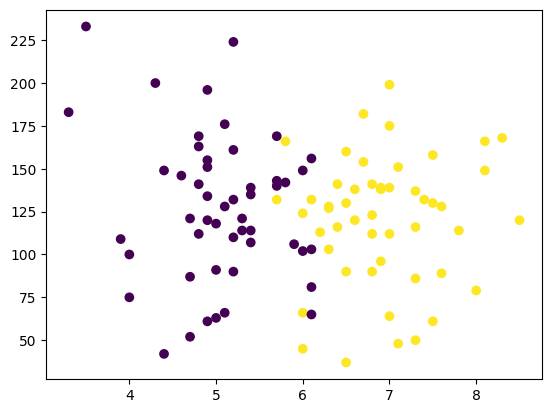

In [11]:
plt.scatter(df['cgpa'], df['iq'], c = df['placement'])

## 03 Extract input and output cols

In [12]:
x = df.iloc[:, 0:2]
y = df.iloc[:, -1]

In [13]:
x

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [14]:
y

,placement
0,1
1,0
2,0
3,1
4,0
...,...
95,0
96,0
97,1
98,1


## 04 Train test split

In [15]:
from sklearn.model_selection import train_test_split

In [16]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.1)

In [17]:
x_train

,cgpa,iq
29,7.0,112.0
20,6.6,120.0
15,5.1,176.0
48,6.6,138.0
9,5.1,66.0
...,...,...
72,7.3,116.0
54,6.4,141.0
44,7.5,61.0
60,6.9,139.0


In [18]:
y_train

,placement
29,1
20,1
15,0
48,1
9,0
...,...
72,1
54,1
44,1
60,1


In [19]:
x_test

,cgpa,iq
90,7.3,86.0
40,4.9,134.0
85,5.8,166.0
47,5.2,161.0
76,4.9,155.0
88,4.4,149.0
10,6.0,45.0
87,5.7,132.0
37,8.1,149.0
50,3.5,233.0


In [20]:
y_test

,placement
90,1
40,0
85,1
47,0
76,0
88,0
10,1
87,1
37,1
50,0


## 05 Scale the values

In [21]:
from sklearn.preprocessing import StandardScaler

In [22]:
scaler = StandardScaler()

In [23]:
x_train = scaler.fit_transform(x_train)

In [24]:
x_train

array([[ 0.86638465, -0.25144915],
       [ 0.50664016, -0.04287382],
       [-0.84240169,  1.41715352],
       [ 0.50664016,  0.42642068],
       [-0.84240169, -1.45075733],
       [-0.93233781, -0.09501765],
       [-0.75246556, -0.82503132],
       [-1.11221006, -0.25144915],
       [-0.75246556,  2.66860553],
       [-1.02227393,  1.93859186],
       [-1.83169904, -1.21611007],
       [ 0.86638465,  0.4524926 ],
       [-0.30278495,  0.47856452],
       [-1.2920823 ,  0.63499602],
       [-1.56189067,  2.04287953],
       [ 1.13619302,  0.40034877],
       [ 1.76574588, -1.11182241],
       [-1.20214618, -0.0168019 ],
       [ 0.68651241,  0.03534193],
       [ 0.23683179,  0.16570152],
       [ 0.41670404, -0.82503132],
       [-1.83169904, -0.56431215],
       [ 0.05695954, -1.05967857],
       [-0.30278495,  0.55678027],
       [-1.20214618, -0.90324707],
       [ 1.40600139, -0.85110324],
       [ 0.68651241, -0.25144915],
       [ 1.85568201,  1.15643435],
       [ 0.23683179,

In [25]:
x_test = scaler.transform(x_test)

In [26]:
x_test

array([[ 1.13619302, -0.92931899],
       [-1.02227393,  0.32213302],
       [-0.21284882,  1.15643435],
       [-0.75246556,  1.02607477],
       [-1.02227393,  0.86964327],
       [-1.47195455,  0.71321177],
       [-0.03297658, -1.99826758],
       [-0.30278495,  0.26998918],
       [ 1.85568201,  0.71321177],
       [-2.28137966,  2.90325278]])

## 06 Train the Model

In [27]:
from sklearn.linear_model import LogisticRegression

In [28]:
clf = LogisticRegression()

In [29]:
clf.fit(x_train, y_train)

LogisticRegression()

## 07  Evaluate the model/model selection

In [30]:
from sklearn.metrics import accuracy_score

In [31]:
y_pred = clf.predict(x_test)

In [32]:
y_test

,placement
90,1
40,0
85,1
47,0
76,0
88,0
10,1
87,1
37,1
50,0


In [33]:
accuracy_score(y_test,y_pred)

0.7

In [34]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

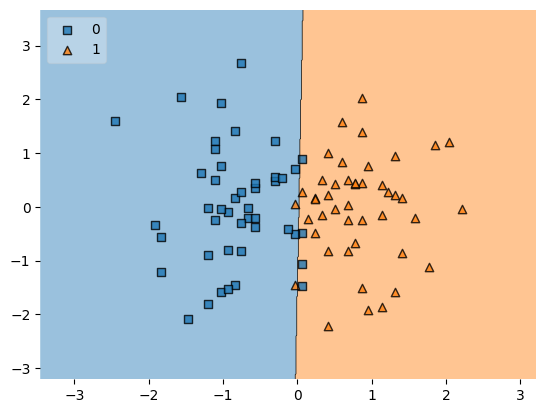

In [35]:
plot_decision_regions(x_train, y_train.values, clf=clf, legend=2)

In [36]:
import pickle

pickle.dump(clf, open('model.pkl', 'wb'))
pickle.dump(scaler, open('scaler.pkl', 'wb'))

In [37]:
%%writefile app.py

import streamlit as st
import pickle
import numpy as np

# Load model and scaler
model = pickle.load(open("model.pkl", "rb"))
scaler = pickle.load(open("scaler.pkl", "rb"))

st.title("🎓 Placement Prediction")
st.write("Enter your CGPA and IQ to predict placement.")

cgpa = st.number_input("Enter CGPA", min_value=0.0, max_value=10.0, value=7.0)
iq = st.number_input("Enter IQ", min_value=50, max_value=200, value=100)

if st.button("Predict"):
    input_data = np.array([[cgpa, iq]])

    # Scale input
    input_scaled = scaler.transform(input_data)

    # Prediction
    prediction = model.predict(input_scaled)

    if prediction[0] == 1:
        st.success("🎉 Student is likely to be Placed!")
    else:
        st.error("❌ Student is likely to be Not Placed.")

Writing app.py


In [54]:
!pip -q install streamlit

In [55]:
!streamlit run app.py --server.address 0.0.0.0 --server.port 8501



2026-10-07 11:19:31.248 Port 8501 is not available


In [56]:
!fuser -k 8501/tcp

8501/tcp:            11822


In [57]:
!curl -I http://localhost:8501

curl: (7) Failed to connect to localhost port 8501 after 0 ms: Couldn't connect to server


In [58]:
!streamlit run app.py --server.address 0.0.0.0 --server.port 8501 > /content/streamlit.log 2>&1 &

In [59]:
!curl -I http://localhost:8501

HTTP/1.1 200 OK
date: Wed, 07 Oct 2026 11:22:18 GMT
server: uvicorn
content-type: text/html; charset=utf-8
accept-ranges: bytes
content-length: 6463
last-modified: Wed, 07 Oct 2026 10:34:51 GMT
etag: "59e76b25736eea499f5042c294dd10ff"
cache-control: no-cache



In [60]:
!/content/cloudflared tunnel --url http://127.0.0.1:8501

2026-10-07T11:23:16Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-10-07T11:23:16Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-10-07T11:23:19Z INF +--------------------------------------------------------------------------------------------+
2026-10-07T11:23:19Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-10-07T11:23:19Z INF |  https://rarely-included-coalition-held.trycloudflare.

In [61]:
!zip -r placement_prediction_project.zip app.py model.pkl scaler.pkl placement.csv

updating: app.py (deflated 49%)
updating: model.pkl (deflated 33%)
updating: scaler.pkl (deflated 30%)
updating: placement.csv (deflated 62%)


In [62]:
from google.colab import files
files.download("placement_prediction_project.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>